In [ ]:
import numpy as np
import math
from math import cos, sin, tan, sqrt
import datetime

In [ ]:
def GS_position(t, h, phi, lamb):
    a = 6378137.0 # meters
    f = 1/298.257223563
    b = (1 - f) * a
    e_squared = 1 - (b/a)**2


    def N(phi):
        return a/sqrt(1-e_squared*sin(phi)**2)
    
    def R_GS_ECEF(phi):
        N_ = N(phi)
        x = (N_ + h)*cos(phi)*cos(lamb)
        y = (N_ + h)*cos(phi)*sin(lamb)
        z = ((1 - e_squared) * N_ + h) * sin(phi)
        return np.array([x, y, z])
    
    def R_3(theta):
        res = np.array([
            [cos(theta), -sin(theta), 0],
            [sin(theta), cos(theta), 0],
            [0, 0, 1]
        ])
        return res


    def greenwich_sidereal_angle(t: datetime.datetime) -> float:
        def datetime_to_julian_date(dt: datetime.datetime) -> float:
            if dt.tzinfo is not None:
                dt = dt.astimezone(datetime.timezone.utc).replace(tzinfo=None)
            year = dt.year
            month = dt.month
            day = dt.day + (dt.hour + dt.minute/60 + dt.second/3600 + dt.microsecond/3.6e9)/24.0
            if month <= 2:
                year -= 1
                month += 12
            A = year // 100
            B = 2 - A + A // 4
            JD = int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5
            return JD
        JD = datetime_to_julian_date(t)
        # ERA fraction (fraction of a rotation since J2000.0)
        frac = 0.7790572732640 + 1.00273781191135448 * (JD - 2451545.0)

        theta = 2.0 * np.pi * (frac % 1.0)
        return theta

    def R_GS_ECI(r_gs_ecef):
        theta = greenwich_sidereal_angle(t)
        r_gs_eci = R_3(theta) @ r_gs_ecef
        return r_gs_eci
    
    return R_GS_ECI(R_GS_ECEF(phi))

def get_velocity_vector(r_gs_eci, t):
    w_0  = 7.2921150e-5
    vector_w = np.array([0, 0, w_0])
    v_gs_eci = np.cross(vector_w, r_gs_eci)
    return v_gs_eci

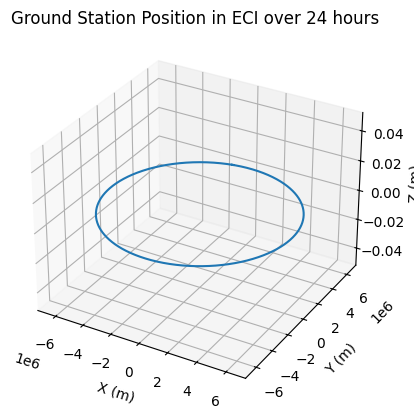

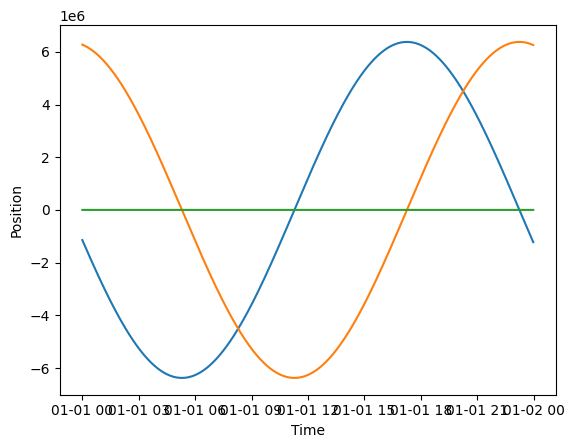

In [ ]:
# verification
import matplotlib.pyplot as plt

times = [datetime.datetime(2026, 1, 1, 0, 0, 0) + datetime.timedelta(seconds=i*60) for i in range(60*24)]

positions = [GS_position(t, 100, math.radians(0), math.radians(0)) for t in times]

xs = [pos[0] for pos in positions]
ys = [pos[1] for pos in positions]
zs = [pos[2] for pos in positions]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, ys, zs)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Ground Station Position in ECI over 24 hours')
plt.show()

plt.figure()
plt.plot(times, xs, label='X (m)')
plt.plot(times, ys, label='Y (m)')
plt.plot(times, zs, label='Z (m)')
plt.xlabel('Time')
plt.ylabel('Position')
plt.show()

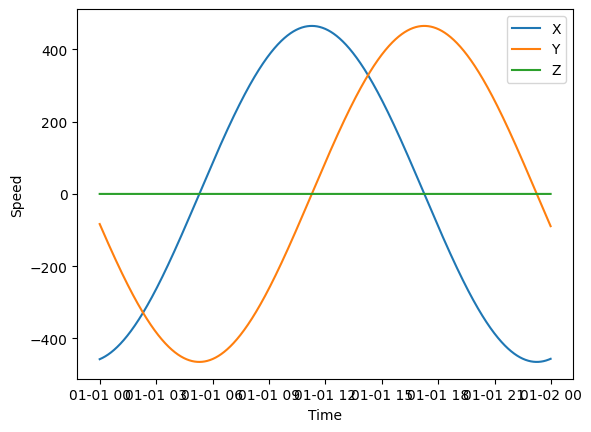

In [ ]:
velocities = [get_velocity_vector(pos, t) for pos, t in zip(positions, times)]
xs = [vel[0] for vel in velocities]
ys = [vel[1] for vel in velocities]
zs = [vel[2] for vel in velocities]
plt.figure()
plt.plot(times, xs, label='X')
plt.plot(times, ys, label='Y')
plt.plot(times, zs, label='Z')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Speed')
plt.show()